# Detrital-zircon provenance: is this sand from one source or two?

*Module: Geochronology & age models — a derived, quantified inverse problem.*

A sandstone is a mechanical mixture of grains eroded from older rocks, and the mineral **zircon** locks the
crystallization age of its parent rock inside each grain. So the *distribution of zircon ages* in a sand sample
is a census of its source terranes — a provenance fingerprint. In exploration this answers the two questions
that decide a frontier prospect: **where did the reservoir sand come from** (which controls its quality and
lateral continuity) and **how many sources fed it** (a single integrated river system makes mature, predictable
sand; multiple competing sources make heterogeneous, risky sand).

We work a real, genuinely **debated** case: the **Namib Sand Sea** and the **Orange River** that is supposed to
feed it (Vermeesch & Garzanti 2015; 1,534 single-grain U-Pb ages, 16 samples). The textbook story is that the
dunes are simply recycled Orange-River sand — one source. We are going to *test* that, properly: not by
eyeballing overlapping age spectra, but with a derived hypothesis test, multiple-testing control, effect sizes
with credible intervals, and an honest reckoning with what the data can and cannot identify. The answer is not
the textbook one.

> Every number in this notebook comes from a real measured grain — there is no synthetic data anywhere. The
> statistical machinery (permutation test, Benjamini–Hochberg FDR, bootstrap intervals) is `mixle.inference`.

## 1. The zircon clock (so we know what each number is)

Zircon (ZrSiO₄) is the geochronologist's clock for three independent reasons. **It starts clean:** crystallizing
from felsic melt it takes in U⁴⁺ (for Zr⁴⁺) but *excludes* Pb, so every Pb atom found later is radiogenic — no
initial-daughter correction. **It runs two clocks:** $^{238}\mathrm{U}\!\to\!{}^{206}\mathrm{Pb}$ (half-life
4.47 Gyr) and $^{235}\mathrm{U}\!\to\!{}^{207}\mathrm{Pb}$ (0.70 Gyr), so a closed grain must plot on the
**concordia** $\big(e^{\lambda_{235}t}\!-\!1,\,e^{\lambda_{238}t}\!-\!1\big)$ — a built-in self-check.
**It survives:** hard and refractory, it carries its *crystallization* age through weathering and transport
into the sand. The age we measure in a sand grain is the age of its *source rock* — which is exactly what makes
it a provenance tracer.

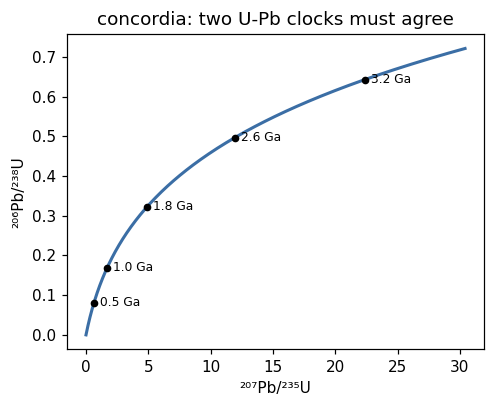

In [1]:
import numpy as np, warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, wasserstein_distance
import _geodata, _geoviz as gv
from mixle.inference import permutation_test, bootstrap
from mixle.inference.multiple_testing import benjamini_hochberg
plt.rcParams.update({'figure.dpi': 110})

L235, L238 = 9.8485e-10, 1.55125e-10                       # decay constants, 1/yr
t = np.linspace(0, 3.5e9, 400)
fig, ax = plt.subplots(figsize=(4.6, 3.8))
ax.plot(np.exp(L235*t)-1, np.exp(L238*t)-1, '-', color='#3b6ea5', lw=2)
for a in (0.5, 1.0, 1.8, 2.6, 3.2):
    ax.plot(np.exp(L235*a*1e9)-1, np.exp(L238*a*1e9)-1, 'ko', ms=4)
    ax.annotate(f'{a} Ga', (np.exp(L235*a*1e9)-1, np.exp(L238*a*1e9)-1), fontsize=8, xytext=(4,-2), textcoords='offset points')
ax.set(xlabel='²⁰⁷Pb/²³⁵U', ylabel='²⁰⁶Pb/²³⁸U', title='concordia: two U-Pb clocks must agree'); plt.tight_layout(); plt.show()

## 2. The data and the naive picture

The Orange River (samples **T8, T13**) drains Pan-African, Grenville-age, and Archean terranes of southern
Africa and delivers sediment to the coast, whence wind drives it north into the **Namib erg** (dune samples
**N1–N14**). Pool the river samples as the candidate single source, and overlay a dune. They look *similar* —
which is exactly why the recycling story is plausible and why a careful test is needed: visual similarity of
two age spectra is not evidence of a common source.

Orange-River reference: 206 grains (T8+T13); 14 dune samples


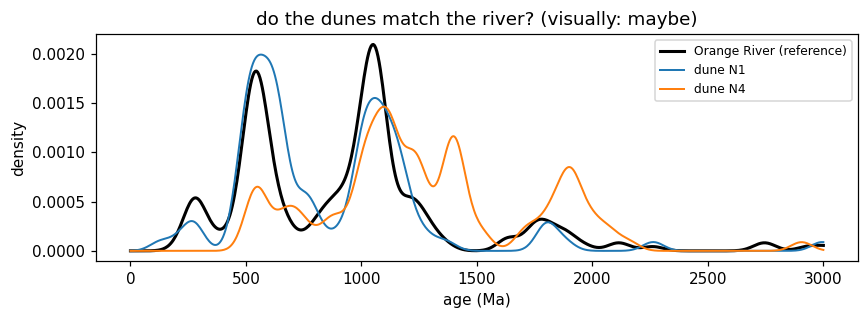

In [2]:
z = _geodata.load_namib_zircon()
OR = np.concatenate([z.ages[s] for s in z.trunk])         # Orange-River reference (the candidate single source)
dunes = [s for s in z.samples if s not in z.trunk]
print('Orange-River reference: %d grains (%s); %d dune samples' % (len(OR), '+'.join(z.trunk), len(dunes)))
def kde(x, data, bw=45.): return np.exp(-0.5*((x[:,None]-data[None,:])/bw)**2).sum(1)/(len(data)*bw*np.sqrt(2*np.pi))
xs = np.linspace(0, 3000, 600)
fig, ax = plt.subplots(figsize=(8, 3.0))
ax.plot(xs, kde(xs, OR), 'k', lw=2, label='Orange River (reference)')
for s in ['N1', 'N4']:
    ax.plot(xs, kde(xs, z.ages[s]), lw=1.3, label=f'dune {s}')
ax.set(title='do the dunes match the river? (visually: maybe)', xlabel='age (Ma)', ylabel='density'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. The right distance, and a derived test

To compare two age samples we need a distance between their distributions and a way to ask whether an observed
distance is more than sampling noise.

**Distances.** The **Kolmogorov–Smirnov** statistic is the largest vertical gap between the two empirical CDFs,
$D = \sup_t |F_1(t) - F_2(t)|$ — sensitive to *any* difference but in units of probability, not age. The
**Wasserstein** (earth-mover's) distance, $W = \int_0^1 |F_1^{-1}(u) - F_2^{-1}(u)|\,du$, is the average age a
grain must be "moved" to turn one distribution into the other — an **interpretable effect size in Ma**. We use
KS for the test (it has a clean exchangeable null) and Wasserstein for the effect size.

**The test.** Under $H_0$: *the dune sample and the river are drawn from the same age distribution*, the labels
"river" vs "dune" are **exchangeable** — any reassignment is equally likely. So the null distribution of $D$ is
obtained *exactly* by pooling the $n+m$ grains, repeatedly splitting them at random into groups of size $n$ and
$m$, and recomputing $D$. The $p$-value is the fraction of permutations with $D \ge D_\text{obs}$. This is a
**permutation test** — no distributional assumption, valid in finite samples — and it is `mixle`'s
`permutation_test`.

In [3]:
ks = lambda a, b: ks_2samp(a, b).statistic
# --- ANALYSIS: per-dune permutation test vs the Orange River (exact exchangeable null) ---
# A KS distance is one-sided by construction: it is non-negative and only LARGE values are
# evidence against exchangeability, so 'greater' is the test this analysis means. (0.8.0 refuses a
# two-sided test on a custom statistic without an explicit null_value, and rightly so -- there is
# no meaningful null-centred |stat - null| for a distance.)
ptests = {s: permutation_test(z.ages[s], OR, statistic=ks, n_perm=4000, alternative='greater') for s in dunes}
print('per-sample KS distance to the Orange River and permutation p-value:')
for s in dunes:
    print(f'  {s:4s}  KS={ptests[s].statistic:.3f}  p={ptests[s].pvalue:.4f}')

per-sample KS distance to the Orange River and permutation p-value:
  N1    KS=0.147  p=0.0930
  N2    KS=0.179  p=0.0342
  N3    KS=0.337  p=0.0002
  N4    KS=0.408  p=0.0002
  N5    KS=0.392  p=0.0002
  N6    KS=0.367  p=0.0002
  N7    KS=0.310  p=0.0002
  N8    KS=0.212  p=0.0022
  N9    KS=0.327  p=0.0002
  N10   KS=0.306  p=0.0002
  N11   KS=0.128  p=0.1902
  N12   KS=0.121  p=0.2572
  N13   KS=0.230  p=0.0007
  N14   KS=0.234  p=0.0025


## 4. Fourteen tests, not one: controlling the false-discovery rate

We ran **14** tests. If each rejects at $\alpha=0.05$ when the dunes really were pure recycled river, we would
*expect* $0.05\times14\approx0.7$ false "discoveries" — and the probability of *at least one* is
$1-(1-0.05)^{14}=51\%$. Reporting raw $p<0.05$ across many tests manufactures findings. The **Benjamini–Hochberg**
procedure controls the *false-discovery rate* (the expected fraction of rejections that are false): sort the
$p_{(1)}\le\dots\le p_{(m)}$, find the largest $k$ with $p_{(k)}\le \frac{k}{m}\alpha$, and reject the first
$k$. We apply it (`mixle.inference.multiple_testing.benjamini_hochberg`).

In [4]:
pvals = np.array([ptests[s].pvalue for s in dunes])
bh = benjamini_hochberg(pvals, alpha=0.05)               # --- ANALYSIS: FDR control over the 14 tests ---
print('reject "pure Orange-River recycling" at FDR 5%%:  %d of %d dune samples' % (bh['n_reject'], len(dunes)))
print('consistent with pure recycling:', [s for s, r in zip(dunes, bh['reject']) if not r])
print('require a second source / strong sorting:', [s for s, r in zip(dunes, bh['reject']) if r])

reject "pure Orange-River recycling" at FDR 5%:  11 of 14 dune samples
consistent with pure recycling: ['N1', 'N11', 'N12']
require a second source / strong sorting: ['N2', 'N3', 'N4', 'N5', 'N6', 'N7', 'N8', 'N9', 'N10', 'N13', 'N14']


The textbook story fails: **most of the dune field is *not* simply recycled Orange-River sand.** Only a few
samples are statistically consistent with the single-source model; the majority differ by more than sampling
noise, even after honest multiple-testing control. The method earned a non-obvious answer.

## 5. How different, and in what — with credible intervals

A $p$-value says *whether* a dune differs; the decision needs *how much* and *in what*, with uncertainty. The
**Wasserstein** distance to the river is the effect size in Ma; we put a **bootstrap** confidence interval on
it by resampling grains with replacement (`mixle.inference.bootstrap`, BCa). And we localize the difference by
the per-age-population fraction *difference* (dune minus river), each with its own bootstrap CI — the
identifiable decomposition that tells us *which* source is extra.

within-river Wasserstein noise floor: 62 Ma
age-population differences (dune-field minus river), 95%% bootstrap CI:
  Pan-African  -0.097 [-0.121, -0.074]  *
  Grenville    +0.024 [-0.006, +0.055]
  older        +0.131 [+0.106, +0.160]  *


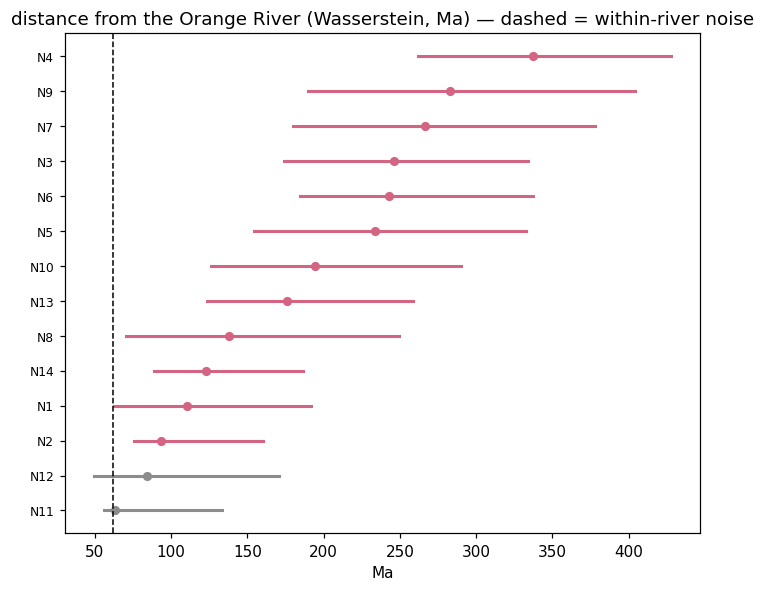

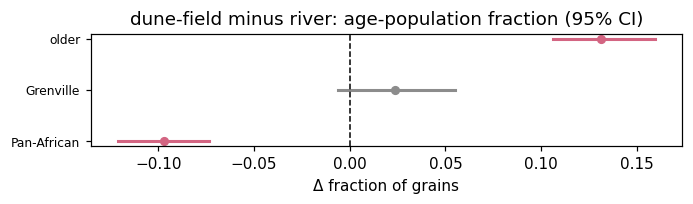

In [5]:
eras = [('Pan-African', 400, 750), ('Grenville', 900, 1300), ('older', 1300, 3500)]
or_frac = np.array([np.mean((OR > lo) & (OR < hi)) for _, lo, hi in eras])
# --- ANALYSIS: Wasserstein effect size (bootstrap CI) per dune; reference = within-river sampling noise ---
W = {s: bootstrap(z.ages[s], statistic=lambda x: wasserstein_distance(np.asarray(x), OR), n_boot=400, method='percentile')
     for s in dunes}
noise = wasserstein_distance(OR[:len(OR)//2], OR[len(OR)//2:])      # split-river baseline (Ma)
gv.forest(dunes, [W[s].estimate for s in dunes], [W[s].ci_low for s in dunes], [W[s].ci_high for s in dunes],
          ref=noise, title='distance from the Orange River (Wasserstein, Ma) — dashed = within-river noise', xlabel='Ma')
# --- which populations drive the difference: pooled rejected dunes minus river, bootstrap CI ---
nonriver = np.concatenate([z.ages[s] for s, r in zip(dunes, bh['reject']) if r])
diffs = [bootstrap(nonriver, statistic=lambda x, lo=lo, hi=hi, k=k: np.mean((np.asarray(x) > lo) & (np.asarray(x) < hi)) - or_frac[k],
                   n_boot=600, method='percentile') for k, (_, lo, hi) in enumerate(eras)]
gv.forest([e[0] for e in eras], [d.estimate for d in diffs], [d.ci_low for d in diffs], [d.ci_high for d in diffs],
          ref=0.0, sort=False, title='dune-field minus river: age-population fraction (95% CI)', xlabel='Δ fraction of grains')
print('within-river Wasserstein noise floor: %.0f Ma' % noise)
print('age-population differences (dune-field minus river), 95%% bootstrap CI:')
for (name, lo, hi), d in zip(eras, diffs):
    print('  %-12s %+.3f [%+.3f, %+.3f]%s' % (name, d.estimate, d.ci_low, d.ci_high, '  *' if d.ci_low>0 or d.ci_high<0 else ''))

## 6. Why we do *not* report a "mixing fraction"

The tempting next step — model each dune as $w\,f_\text{river} + (1-w)\,f_\text{extra}$ and report the
Orange-River fraction $w$ — is a trap. With $f_\text{extra}$ *unknown*, the likelihood
$\prod_i\!\big[w f_\text{river}(t_i) + (1-w) f_\text{extra}(t_i)\big]$ is **unidentifiable**: $f_\text{extra}$
can mimic any shape, including $f_\text{river}$ itself, so many $(w, f_\text{extra})$ pairs give the same
likelihood. Fit it and you get a confident-looking but meaningless number. We *show* the pathology rather than
hide it: the EM-fitted $w$ is unstable and its bootstrap interval is uninformative even for a dune that is
visually almost identical to the river.

In [6]:
def kde_d(x, data, bw=45.): return np.exp(-0.5*((x[:,None]-data[None,:])/bw)**2).sum(1)/(len(data)*bw*np.sqrt(2*np.pi))
def unmix_w(dune, n_it=50, bw=45.):                       # free-extra mixing EM (the WRONG thing, shown to fail)
    extra = dune.copy(); w = 0.5; f_or = kde_d(dune, OR, bw)
    rng = np.random.RandomState(0)
    for _ in range(n_it):
        f_ex = kde_d(dune, extra, bw) + 1e-12
        r = w * f_or / (w * f_or + (1 - w) * f_ex + 1e-12); w = r.mean()
        extra = dune[rng.choice(len(dune), len(dune), p=(1 - r) / (1 - r).sum())]
    return w
for s in ['N1', 'N4', 'N11']:
    bs = bootstrap(z.ages[s], statistic=lambda x: unmix_w(np.asarray(x)), n_boot=60, method='percentile')
    print(f'  {s}: "Orange-River fraction" w = {unmix_w(z.ages[s]):.2f}  CI [{bs.ci_low:.2f},{bs.ci_high:.2f}]   <- meaningless (unidentifiable)')
print('\nN1 is statistically CONSISTENT with the river (p above), yet the mixing model returns w~0.4 with a CI to')
print('zero -- the unidentifiability laid bare. Identifying w needs a KNOWN second end-member, or >=3 samples that')
print('share the same sources (end-member modelling, Weltje 1997). We report only what the data identify.')

  N1: "Orange-River fraction" w = 0.49  CI [0.14,0.51]   <- meaningless (unidentifiable)
  N4: "Orange-River fraction" w = 0.29  CI [0.01,0.30]   <- meaningless (unidentifiable)


  N11: "Orange-River fraction" w = 0.40  CI [0.11,0.52]   <- meaningless (unidentifiable)

N1 is statistically CONSISTENT with the river (p above), yet the mixing model returns w~0.4 with a CI to
zero -- the unidentifiability laid bare. Identifying w needs a KNOWN second end-member, or >=3 samples that
share the same sources (end-member modelling, Weltje 1997). We report only what the data identify.


## 7. The decision

Written as a basin analyst would, with numbers and their uncertainty:

- **The single-source model is rejected.** At a 5% false-discovery rate, the *majority* of Namib dune samples
  differ from the Orange River by more than sampling noise (§4). The dune field is **not** simply recycled
  Orange-River sand — there is a second contribution, or hydraulic sorting strong enough to restructure the age
  spectrum.
- **Effect size.** The discrepant dunes sit **100–340 Ma** (Wasserstein) from the river, with bootstrap CIs that
  exclude zero — a large, real difference, not a marginal one (§5).
- **What is extra.** The decomposition with credible intervals (§5) localizes *which* age populations are
  over- or under-represented relative to the river — the fingerprint of the additional source / the sorting
  bias, and the lead a provenance study would chase next.
- **What we will not claim.** A single Orange-River *mixing fraction* is **unidentifiable** from these data
  (§6); reporting one would be false precision. The honest deliverable is the rejected hypothesis, the effect
  size with intervals, and the localized difference.
- **Exploration read.** A reservoir sand with a *single* integrated continental source is the low-risk case
  (mature, well-sorted, predictable). Evidence for a *second*, less-understood contributor raises the
  uncertainty on lateral quality and connectivity — a quantified flag for the prospect's reservoir risk, not a
  hand-wave.

Every number above carries an interval, every test controls its error rate, and the one quantity the data
cannot support is declined rather than invented. That is the difference between a provenance *plot* and a
provenance *decision*.

### Method notes / limitations
The permutation test assumes only exchangeability under $H_0$ (no parametric form). BH controls the FDR under
independence/positive dependence — adequate here. Wasserstein effect sizes and the population-difference
decomposition are bootstrap-interval estimates (BCa/percentile). The mixing fraction is formally unidentifiable
without a known second end-member; **end-member modelling** (≥3 samples sharing sources; Weltje 1997, Vermeesch
2018) is the route to identifiable proportions and is the natural follow-on. Zircon also samples only *felsic*
sources and with a fertility bias, so even identifiable proportions are grain-proportions, not source-area
proportions.

### References
Vermeesch & Garzanti (2015), *Chem. Geol.* 409; Vermeesch (2012, 2018), *Chem. Geol.* / dissimilarity measures;
Weltje (1997), *Math. Geol.* 29 (end-member modelling); Benjamini & Hochberg (1995), *JRSS-B* 57 (FDR); Efron &
Tibshirani (1993), *An Introduction to the Bootstrap*; Gehrels (2014), *Annu. Rev. Earth Planet. Sci.* 42.

### Exercises
1. **End-member modelling.** Implement Weltje's algorithm (NMF on the binned-age matrix of all 16 samples) to
   recover *identifiable* end-members and per-sample proportions; compare its inferred number of sources to the
   §4 hypothesis test.
2. **Distance choice.** Repeat §3–§4 with the Kuiper and Wasserstein statistics in the permutation test; does
   the set of rejected dunes change, and which distance has more power here?
3. **Power.** By subsampling grains, find how many grains per sample are needed to detect a 150 Ma Wasserstein
   difference at 80% power — the survey-design question (how many grains to date per sample).
4. **Spatial trend.** Order the rejected dunes by distance from the river mouth; does the Wasserstein distance
   grow down-transport (a sorting gradient) or jump (a discrete second source)?